Code to set path root

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.3
    ),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  34


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  8


### Using Model Architecture:
* 3 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

In [7]:
model.add(
    # First Layer
    nn.Conv2d(3, 12, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(12),
    nn.MaxPool2d(2, 2),

    # Second Layer
    nn.Conv2d(12, 24, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(24),
    nn.MaxPool2d(2, 2),

    # Third Layer
    nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(48),
    nn.MaxPool2d(2, 2),

    # Flatten
    nn.Flatten(),

    # Fully connected layer (for 64x64 input)
    nn.Linear(48 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

Architecture(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): ReLU()
      (10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Flatten(start_dim=1, end_dim=-1)
      (13): Linear(in_features=3072, out_featu

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment1/",
    save_checkpoints=1,
    print_every=10
    )

In [10]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.4742 | Val Loss: 0.8739 | Train Acc: 0.8171 | Val Acc: 0.6881 | Train F1: 0.8174 | Val F1: 0.6925
Epoch [20/100] | Train Loss: 0.2533 | Val Loss: 2.7744 | Train Acc: 0.9197 | Val Acc: 0.5531 | Train F1: 0.9203 | Val F1: 0.4761
Epoch [30/100] | Train Loss: 0.1824 | Val Loss: 1.2170 | Train Acc: 0.9381 | Val Acc: 0.7124 | Train F1: 0.9385 | Val F1: 0.7109
Epoch [40/100] | Train Loss: 0.1405 | Val Loss: 1.7824 | Train Acc: 0.9589 | Val Acc: 0.6040 | Train F1: 0.9591 | Val F1: 0.6036
Epoch [50/100] | Train Loss: 0.1032 | Val Loss: 3.4850 | Train Acc: 0.9759 | Val Acc: 0.4513 | Train F1: 0.9761 | Val F1: 0.3626
Epoch [60/100] | Train Loss: 0.0617 | Val Loss: 0.6672 | Train Acc: 0.9825 | Val Acc: 0.8296 | Train F1: 0.9825 | Val F1: 0.8300
Epoch [70/100] | Train Loss: 0.0401 | Val Loss: 0.7631 | Train Acc: 0.9924 | Val Acc: 0.8518 | Train F1: 0.9924 | Val F1: 0.8522
Epoch [80/100] | Train Loss: 0.0645 | Val Loss: 0.8152 | Train Acc: 0.9783 | Val Acc: 0.8496 | Tr

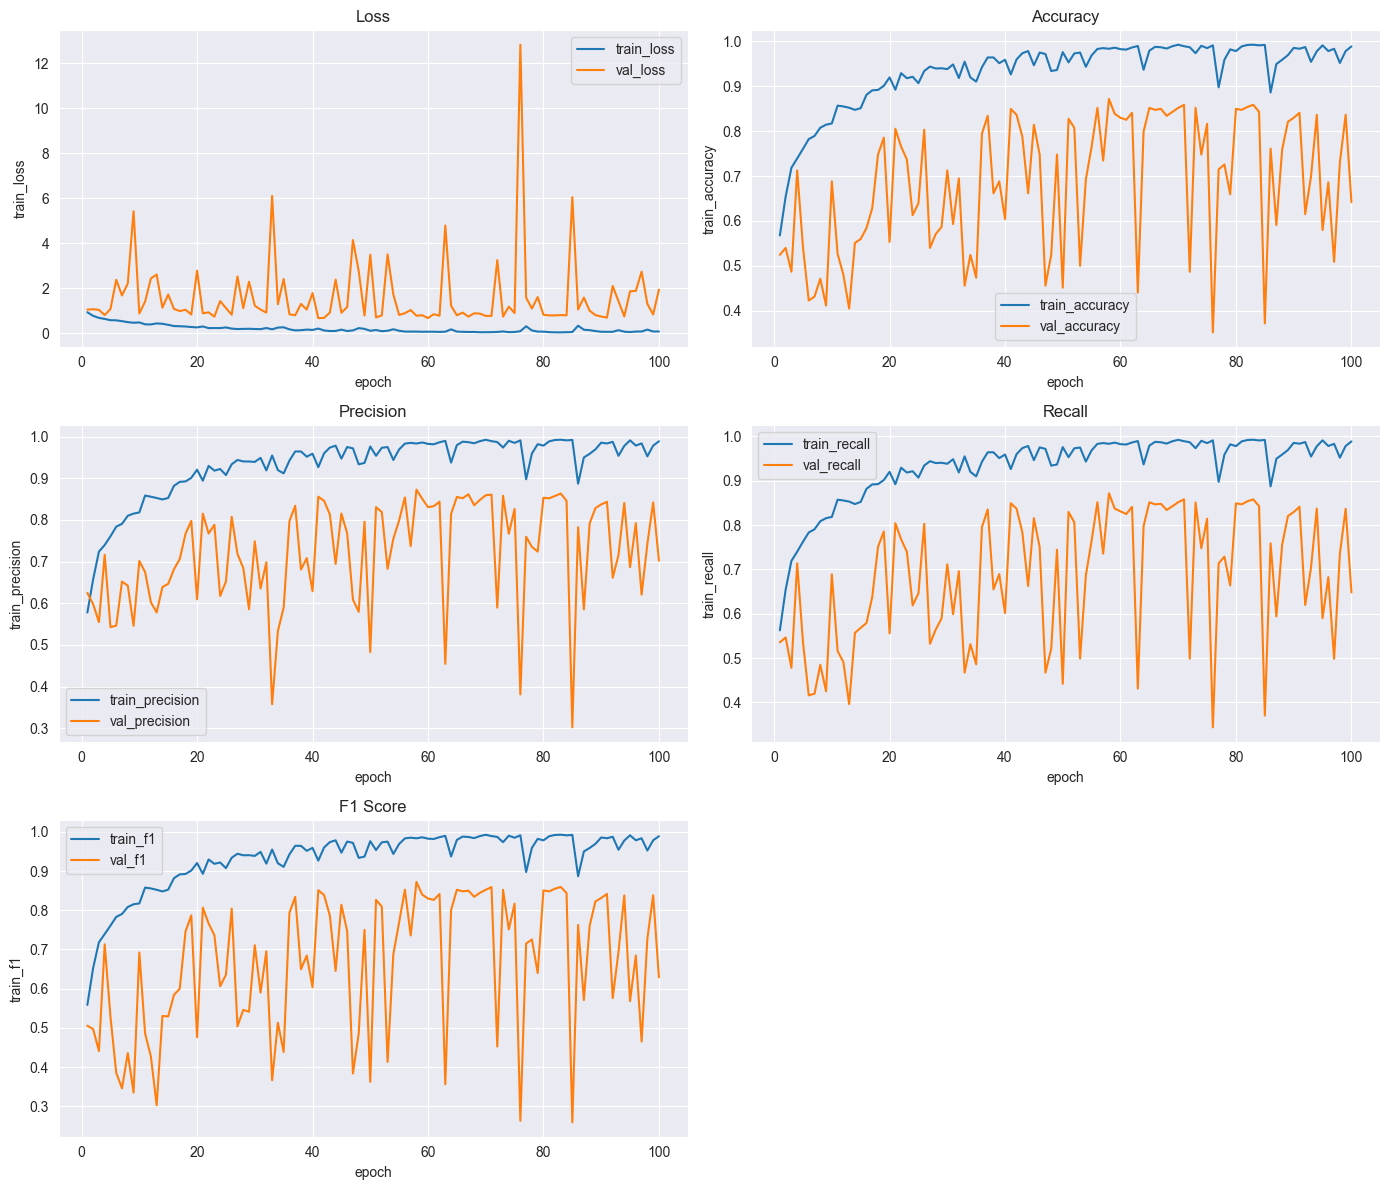

In [11]:
df = plot_training_metrics(history)

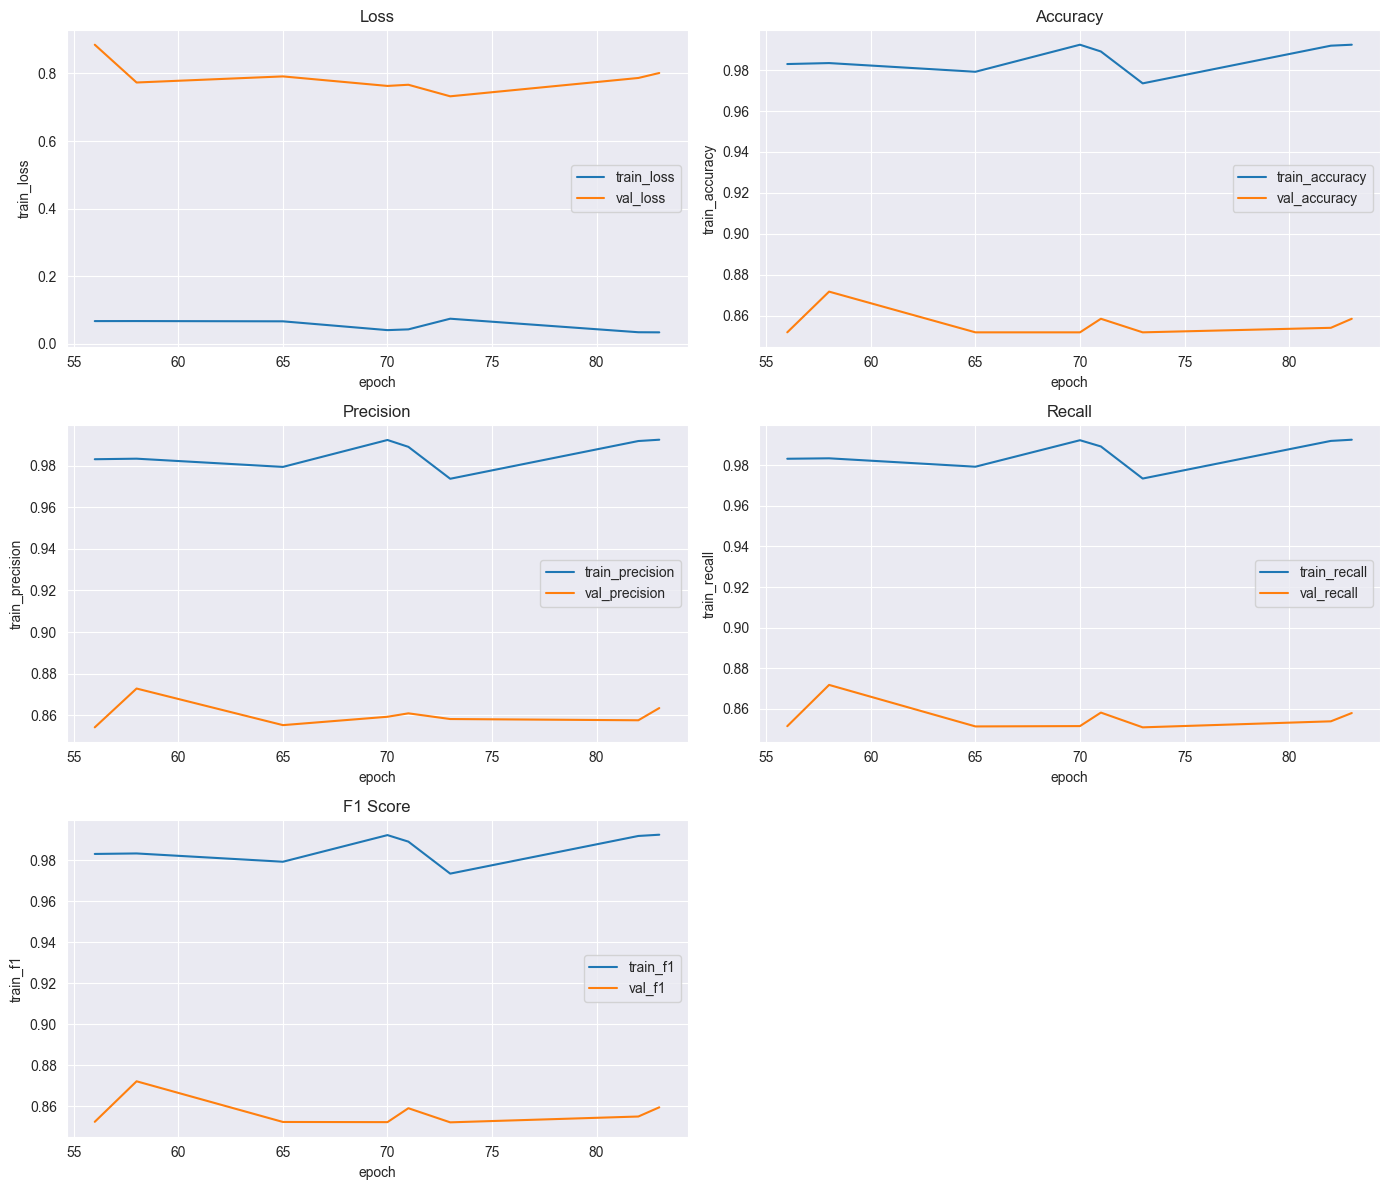

In [18]:
filtered_df = df[
    (df["val_accuracy"] >= 0.85) &
    (df["val_f1"] >= 0.85)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

In [19]:
high_accuracy_df

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,confusion_matrix
55,56,0.066834,0.885061,0.982987,0.983162,0.983181,0.983170,0.851770,0.854142,0.851428,0.852366,"[[tensor(120), tensor(10), tensor(12)], [tenso..."
57,58,0.066941,0.773200,0.983459,0.983428,0.983400,0.983411,0.871681,0.872816,0.871766,0.872153,"[[tensor(124), tensor(7), tensor(11)], [tensor..."
64,65,0.066156,0.791239,0.979206,0.979468,0.979270,0.979364,0.851770,0.855205,0.851312,0.852293,"[[tensor(118), tensor(6), tensor(18)], [tensor..."
69,70,0.040101,0.763053,0.992439,0.992425,0.992314,0.992366,0.851770,0.859233,0.851476,0.852213,"[[tensor(117), tensor(5), tensor(20)], [tensor..."
70,71,0.042341,0.766514,0.989130,0.989119,0.989248,0.989181,0.858407,0.860885,0.858130,0.859008,"[[tensor(120), tensor(8), tensor(14)], [tensor..."
72,73,0.073895,0.732323,0.973535,0.973765,0.973432,0.973558,0.851770,0.858140,0.850861,0.852110,"[[tensor(115), tensor(5), tensor(22)], [tensor..."
81,82,0.033849,0.786602,0.991966,0.991926,0.991980,0.991952,0.853982,0.857544,0.853828,0.854956,"[[tensor(120), tensor(7), tensor(15)], [tensor..."
82,83,0.033544,0.801329,0.992439,0.992555,0.992564,0.992559,0.858407,0.863420,0.857906,0.859450,"[[tensor(119), tensor(7), tensor(16)], [tensor..."


In [20]:
df

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,confusion_matrix
0,1,0.925722,1.044178,0.567580,0.577859,0.562510,0.558660,0.524336,0.624962,0.535553,0.505763,"[[tensor(127), tensor(6), tensor(9)], [tensor(..."
1,2,0.765837,1.061210,0.654064,0.657428,0.654200,0.652878,0.539823,0.597878,0.546516,0.496897,"[[tensor(121), tensor(16), tensor(5)], [tensor..."
2,3,0.676441,1.032289,0.718336,0.723961,0.719227,0.718271,0.486726,0.554809,0.478016,0.441150,"[[tensor(20), tensor(35), tensor(87)], [tensor..."
3,4,0.630642,0.802048,0.739130,0.739881,0.740012,0.739307,0.712389,0.716402,0.713697,0.713093,"[[tensor(106), tensor(13), tensor(23)], [tenso..."
4,5,0.573771,1.069269,0.760397,0.760739,0.762250,0.760771,0.542035,0.542806,0.535986,0.528514,"[[tensor(48), tensor(45), tensor(49)], [tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0.067928,1.879231,0.978261,0.978460,0.978321,0.978366,0.685841,0.792372,0.682582,0.684647,"[[tensor(92), tensor(45), tensor(5)], [tensor(..."
96,97,0.070944,2.733483,0.983459,0.983717,0.983233,0.983448,0.508850,0.620677,0.498210,0.465337,"[[tensor(28), tensor(72), tensor(42)], [tensor..."
97,98,0.155083,1.298458,0.951796,0.952670,0.952009,0.952187,0.730088,0.742971,0.735115,0.728047,"[[tensor(127), tensor(3), tensor(12)], [tensor..."
98,99,0.070816,0.827533,0.978261,0.978235,0.978430,0.978323,0.836283,0.842001,0.836677,0.838178,"[[tensor(120), tensor(7), tensor(15)], [tensor..."
